# Análisis Exploratorio de Olist

## índice 
1. Introducción 
2. Carga de dataset
3. Información general del dataset

4. Ventas
- KPIs
- Evolución de venta mensuales 
- Top clientes por ingresos 
- Top ventsa por estados 

5. Lógística 
- KPIs
- Distribución tiempo de entrega
- Número de pedidos según retraso
- Tiempo mediode entrega según retraso
- Comparativa logística por estado

6. Cliente 
- KPIs 
- Distribución de clientes 
- Clientes por estado
- Curva de parapeto de clientes

7. Satisfacción 
- KPIs
- Distribución de reviews
- Relación entre retraso y satisfacción 
- Satisfacción por categoría y estado
### Conclusión 
### Modelo de Machine Learning
---


1. Introducción 

Vamos a contestar a la siguiente pregunta: 

- ¿Qué factores influyen en la satisfacción del cliente?

Haciendo un análisis exploratorio y un modelo predictivo que nos ayudará a integrar las ventas, la logística y el comportamiento del cliente para identificar los principales drivers de satisfacción y desarrollar un modelo predictivo del review score.

In [1]:
# Importación de librerías 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import sidetable as stb
import numpy as np


---

2. Carga del dataset 


In [2]:
df = pd.read_csv(
    "../data/processed/olist_final_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "shipping_limit_date",
        "review_creation_date",
        "review_answer_timestamp"
    ]
)
df_olist = df.copy()

In [3]:
# Ver todas las columnas 
pd.set_option("display.max_columns", None)

In [4]:
df_olist.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,delivery_delay,id_customer_order,id_user,customer_zip,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,id_product,weight_g,lengh_cm,heigh_cm,width_cm,category_pt,category_en,id_seller,seller_zip,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,city,state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,3149,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,87285b34884572647811a353c7ac498a,500.0,19.0,8.0,13.0,utilidades_domesticas,housewares,3504c0cb71d7fa48d967e0e4c94d59d9,9350,1,credit_card,1,18.12,a54f0611adc9ed256b57ede6b6eb5114,4,No comment,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,Sao Paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,3149,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,87285b34884572647811a353c7ac498a,500.0,19.0,8.0,13.0,utilidades_domesticas,housewares,3504c0cb71d7fa48d967e0e4c94d59d9,9350,3,voucher,1,2.00,a54f0611adc9ed256b57ede6b6eb5114,4,No comment,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,Sao Paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,3149,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,87285b34884572647811a353c7ac498a,500.0,19.0,8.0,13.0,utilidades_domesticas,housewares,3504c0cb71d7fa48d967e0e4c94d59d9,9350,2,voucher,1,18.59,a54f0611adc9ed256b57ede6b6eb5114,4,No comment,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,Sao Paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,-6,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,47813,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,595fac2a385ac33a80bd5114aec74eb8,400.0,19.0,13.0,19.0,perfumaria,perfumery,289cdb325fb7e7f891c38608bf9e0962,31570,1,ticket,1,141.46,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,Barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,-18,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,75265,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,aa4383b373c6aca5d8797843e5594415,420.0,24.0,19.0,21.0,automotivo,auto,4869f7a5dfa277a7dca6462dcf3b52b2,14840,1,credit_card,3,179.12,e73b67b67587f7644d5bd1a52deb1b01,5,No comment,No comment,2018-08-18,2018-08-22 19:07:58,Vianopolis,GO


---

3. Información dataset

In [5]:
# Dimensiones del dataset

print("filas: ", df_olist.shape[0])
print("Columnas: ", df_olist.shape[1])

filas:  114858
Columnas:  40


In [6]:
# Información general
df_olist.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114858 entries, 0 to 114857
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       114858 non-null  object        
 1   customer_id                    114858 non-null  object        
 2   order_status                   114858 non-null  object        
 3   order_purchase_timestamp       114858 non-null  datetime64[ns]
 4   order_approved_at              114843 non-null  datetime64[ns]
 5   order_delivered_carrier_date   114857 non-null  datetime64[ns]
 6   order_delivered_customer_date  114858 non-null  datetime64[ns]
 7   order_estimated_delivery_date  114858 non-null  datetime64[ns]
 8   delivery_time_days             114858 non-null  int64         
 9   delivery_delay                 114858 non-null  int64         
 10  id_customer_order              114858 non-null  object        
 11  

In [7]:
# Tipos de datos 
df_olist.dtypes.value_counts()

object            18
int64              8
datetime64[ns]     7
float64            7
Name: count, dtype: int64

In [8]:
# Comprovación de valores nulos 

nulos = df_olist.isnull().sum().value_counts(ascending=False)
nulos_percentil = (nulos/len(df_olist))*100

nulos_df_olist = pd.DataFrame(
    {"Nulos": nulos, 
    "Percentil": nulos_percentil
})

nulos_df_olist[nulos_df_olist["Nulos"]>0]

,Nulos,Percentil
0,38,0.033084
15,1,0.000871
1,1,0.000871


In [9]:
df_olist.stb.missing()

,missing,total,percent
order_approved_at,15,114858,0.013060
order_delivered_carrier_date,1,114858,0.000871
order_id,0,114858,0.000000
customer_id,0,114858,0.000000
order_purchase_timestamp,0,114858,0.000000
order_status,0,114858,0.000000
order_delivered_customer_date,0,114858,0.000000
order_estimated_delivery_date,0,114858,0.000000
delivery_time_days,0,114858,0.000000
delivery_delay,0,114858,0.000000


In [10]:
# Duplicados 
df_olist.duplicated().sum()

np.int64(0)

In [11]:
# Estadísticas generales 
df_olist.describe().T

,count,mean,min,25%,50%,75%,max,std
order_purchase_timestamp,114858,2017-12-31 12:59:45.538839040,2016-10-03 09:44:50,2017-09-12 19:18:25.249999872,2018-01-19 01:35:12,2018-05-04 14:00:06.249999872,2018-08-29 15:00:37,NaN
order_approved_at,114843,2018-01-01 00:25:49.472445440,2016-10-04 09:43:32,2017-09-13 08:45:14,2018-01-19 14:34:12,2018-05-04 21:21:56,2018-08-29 15:10:26,NaN
order_delivered_carrier_date,114857,2018-01-03 19:42:05.910984960,2016-10-08 10:34:01,2017-09-15 13:52:41,2018-01-23 19:18:49,2018-05-08 08:27:00,2018-09-11 19:48:28,NaN
order_delivered_customer_date,114858,2018-01-12 23:40:18.665604352,2016-10-11 13:46:32,2017-09-23 00:28:20.500000,2018-02-01 16:15:39.500000,2018-05-15 14:03:23.500000,2018-10-17 13:22:46,NaN
order_estimated_delivery_date,114858,2018-01-24 08:58:50.230371328,2016-10-27 00:00:00,2017-10-04 00:00:00,2018-02-15 00:00:00,2018-05-25 00:00:00,2018-10-25 00:00:00,NaN
delivery_time_days,114858.0,11.979375,0.0,6.0,10.0,15.0,208.0,9.371316
delivery_delay,114858.0,-12.084574,-147.0,-17.0,-13.0,-7.0,188.0,10.094451
customer_zip,114858.0,35086.038622,1003.0,11250.0,24310.0,58884.0,99980.0,29874.542693
order_item_id,114858.0,1.194597,1.0,1.0,1.0,1.0,21.0,0.685723
shipping_limit_date,114858,2018-01-07 03:35:23.095761664,2016-10-08 10:34:01,2017-09-19 20:43:39.750000128,2018-01-25 19:09:35,2018-05-10 12:14:49,2020-04-09 22:35:08,NaN


---

4. Ventas

- KPIs

In [12]:

total_revenue = df_olist["payment_value"].sum()
total_orders = df_olist["order_id"].nunique()
avg_order_value = df_olist.groupby("order_id")["payment_value"].sum().mean(
)

print("Revenue total: ", round(total_revenue,2))
print("Total pedidos: ", total_orders)
print("Ticket medio: ", round(avg_order_value,2))

Revenue total:  19669786.3
Total pedidos:  95829
Ticket medio:  205.26


- El negocio ha generado cerca de 19.7 millones de euros en ingresos totales, lo que refleja un alto volumnen de ventas y una fuerte actividad comercial 
- Se han realizado un total de 95.829 pedidos, lo que eleva la demanda y un flujo de transacciones en la plataforma.
- Cada pedido tiene un valor medio de 205,25 euros , lo que muestra que los clientes realizan compras de importe moderado, diendo clave para las estrategias de incremento de gasto por pedido.

- Evolución de ventas mensuales 

In [13]:
# Crear columna mes-año
df_olist["year_month"] = df_olist["order_purchase_timestamp"].dt.to_period("M").astype(str)

In [14]:
# Ventas por mes 
ventas_mes = df_olist.groupby("year_month").agg({
    "payment_value": "sum", 
    "order_id": "nunique"
}).reset_index()

ventas_mes= ventas_mes.sort_values("year_month")

<function matplotlib.pyplot.show(close=None, block=None)>

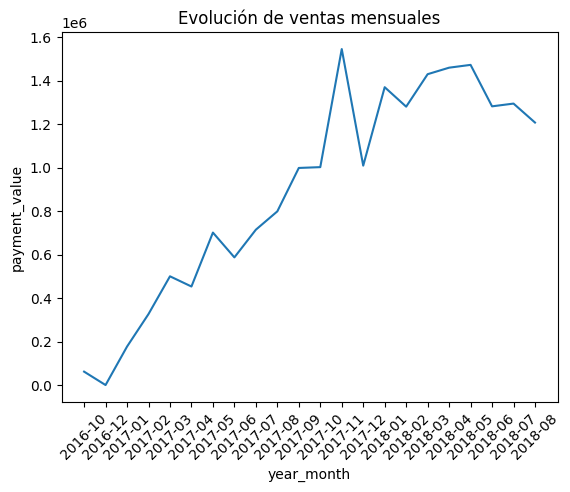

In [15]:
plt.Figure(figsize=(12,5))
sns.lineplot(data=ventas_mes, x= "year_month", y = "payment_value")
plt.xticks(rotation =45)
plt.title("Evolución de ventas mensuales")
plt.show

Las ventas muestran una tendencia claramente creciente a lo largo del tiempo, alcanzando su punto máximo a finales de 2017. Posteriormente, se observa cierta estabilidad con ligeras fluctuaciones, lo que indica que Olist ha pasado de una fase de crecimiento a una etapa de consolidación.

- Top categorías

In [16]:
top_categories = df_olist.groupby("category_en").agg({
    "payment_value": "sum"
}).sort_values("payment_value", ascending=False).head(10)

<function matplotlib.pyplot.show(close=None, block=None)>

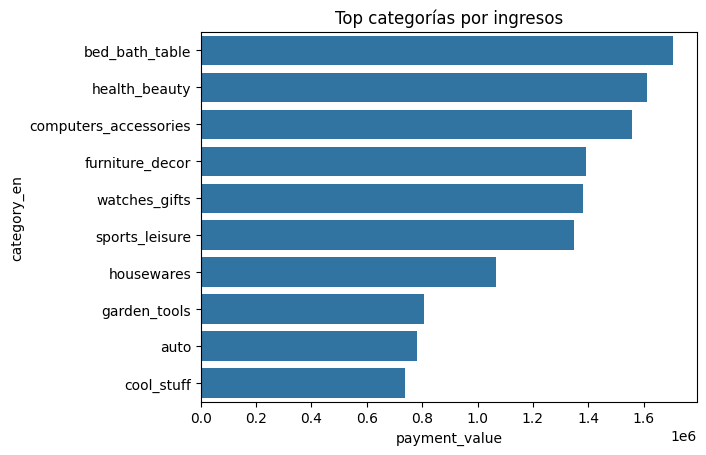

In [17]:
plt.Figure(figsize=(10,5))
sns.barplot(data=top_categories.reset_index(),x="payment_value", y= "category_en")
plt.title("Top categorías por ingresos")
plt.show

Las categorías que generan mayores ingresos son bed_bath_table, health_beauty y computers_accessories, lo que indica que los productos relacionados con el hogar, la belleza y la tecnología tienen una alta demanda. Esto sugiere que estas categorías son clave para el negocio y pueden ser prioritarias en estrategias comerciales.

- Ventas por estado

In [18]:
ventas_estados= df_olist.groupby("state").agg({
    "payment_value": "sum"
}).sort_values("payment_value", ascending=False).head(10)

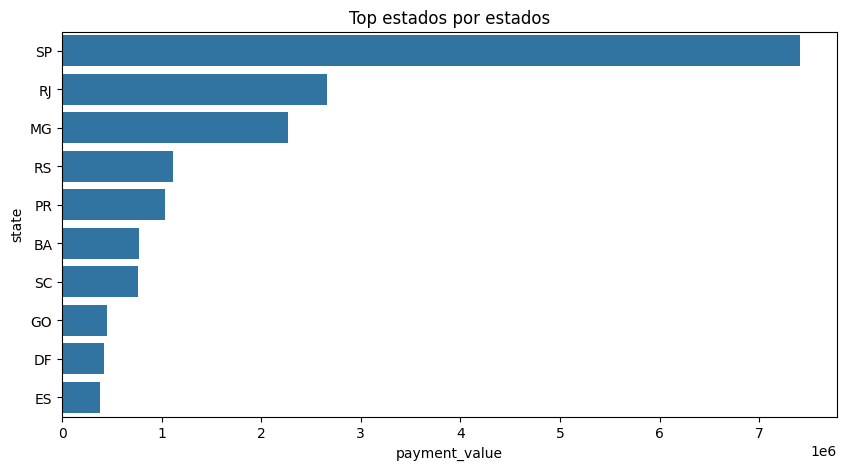

In [19]:
plt.figure(figsize=(10,5))
sns.barplot(data=ventas_estados.reset_index(), x="payment_value", y="state")
plt.title("Top estados por estados")
plt.show()

El estado de São Paulo (SP) concentra la mayor parte de los ingresos, muy por encima del resto, seguido de Río de Janeiro (RJ) y Minas Gerais (MG). Esto refleja una fuerte concentración geográfica del negocio en las principales regiones económicas del país.

---

5. Logística 

- KPIs

In [20]:

avg_delivery_time = df_olist["delivery_time_days"].mean()
avg_delay = df_olist["delivery_delay"].mean()
pct_delayed = (df_olist["delivery_delay"]>0).mean()*100

print("Tiempo medio de entrega:", round(avg_delivery_time,2))
print("Retraso medio:", round(avg_delay,2))
print("% pedidos retrasados:", round(pct_delayed, 2))

Tiempo medio de entrega: 11.98
Retraso medio: -12.08
% pedidos retrasados: 6.41


- Los pedidos tardan de media casi 12 días en ser entregados, lo que refleja el tiempo estandar del proceso logístico desde la compra hasta la recepción del producto.
- En promedio, los pedidos se entregan con más de 12 días de antelación repecto a la fecha estimada, lo que indica una alta eficiendia logística y cumplimiento de plazos.
- Solo el 6,41% de los pedidos presentan retrasos, lo que muestra un bajo nivel de incidencias en la entrega y un buen desempeño general del sistema logístico.

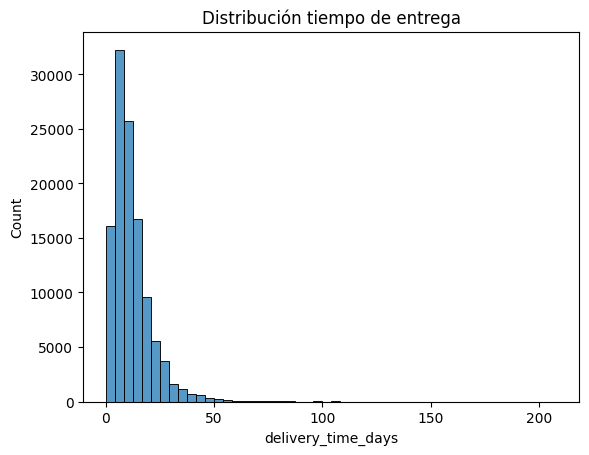

In [21]:
# Ditribución tiempo de entrega
plt.Figure(figsize=(10,5))
sns.histplot(df_olist["delivery_time_days"], bins=50)
plt.title("Distribución tiempo de entrega")
plt.show()

La mayoría de los pedidos se entregan en un rango de pocos días (aprox. entre 5 y 20 días), aunque existe una cola larga con algunos casos extremos de entregas muy tardías. Esto indica que el sistema logístico es generalmente eficiente, pero presenta ciertas incidencias puntuales.

In [22]:
# Retrasos 
df_olist["delay_flag"] = df_olist["delivery_delay"].apply(lambda x:1 if x>0 else 0)

delay_analysis = df_olist.groupby("delay_flag").agg({
    "order_id":"nunique", 
    "delivery_time_days": "mean"
}).reset_index()

In [23]:
logistica_estado = df.groupby("state").agg({
    "delivery_time_days": "mean",
    "delivery_delay": "mean"
}).sort_values("delivery_delay", ascending=False)

In [24]:
delay_analysis["delay_status"] = delay_analysis["delay_flag"].map({
    0: "En plazo o antes",
    1: "Con retraso"
})

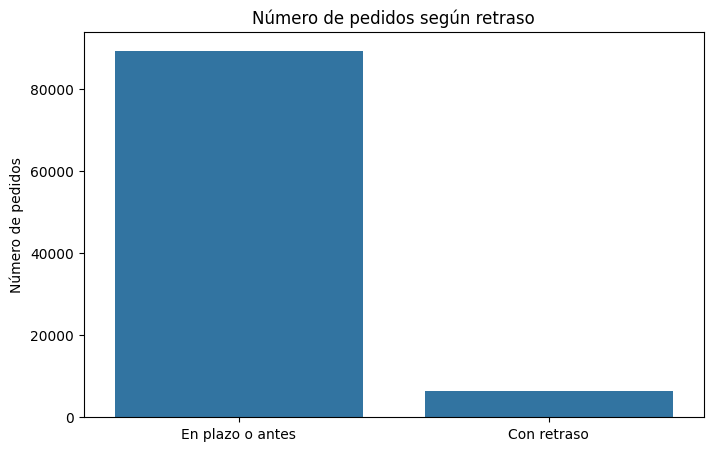

In [25]:
# Número de pedidos según retraso
plt.figure(figsize=(8,5))

sns.barplot(
    data=delay_analysis,
    x="delay_status",
    y="order_id"
)

plt.title("Número de pedidos según retraso")
plt.xlabel("")
plt.ylabel("Número de pedidos")

plt.show()

La gran mayoría de los pedidos se entregan en plazo o incluso antes de la fecha estimada, mientras que solo una pequeña proporción presenta retrasos. Esto confirma un buen desempeño general del servicio logístico.

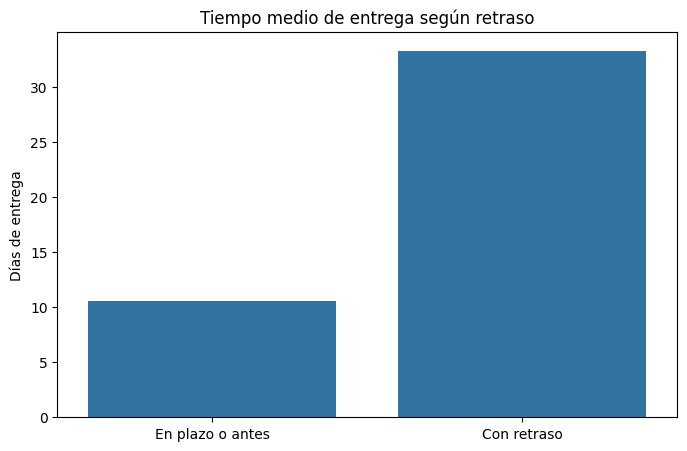

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=delay_analysis,
    x="delay_status",
    y="delivery_time_days"
)

plt.title("Tiempo medio de entrega según retraso")
plt.xlabel("")
plt.ylabel("Días de entrega")

plt.show()

Los pedidos entregados en plazo tienen un tiempo medio de entrega de aproximadamente 10 días, mientras que los pedidos retrasados alcanzan tiempos cercanos a los 30 días o más. Esto muestra que los retrasos no solo afectan al cumplimiento, sino que implican un aumento significativo en el tiempo de entrega.

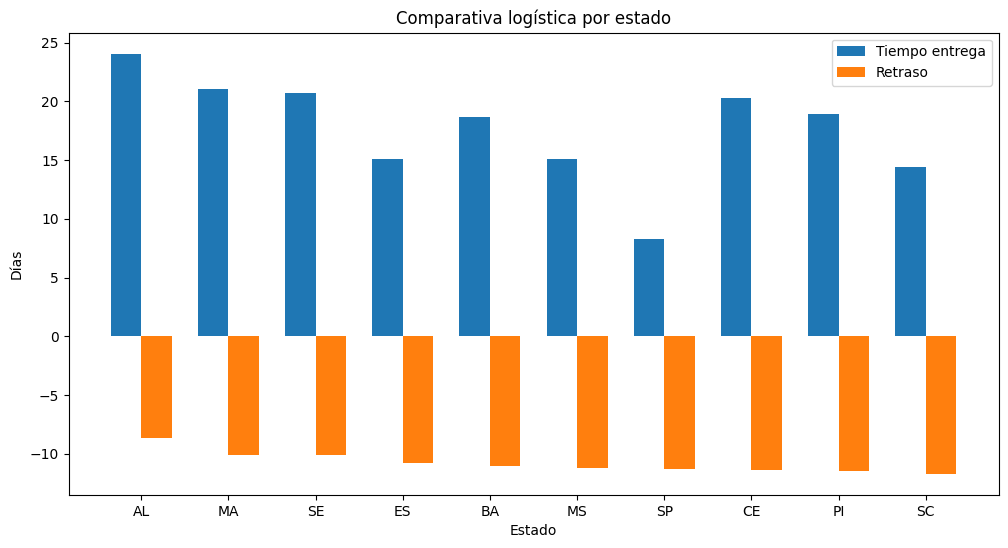

In [27]:
top_logistica_estado = (
    logistica_estado
    .sort_values("delivery_delay", ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12,6))

x = np.arange(len(top_logistica_estado))
width = 0.35

ax.bar(x - width/2, top_logistica_estado["delivery_time_days"], width, label="Tiempo entrega")
ax.bar(x + width/2, top_logistica_estado["delivery_delay"], width, label="Retraso")

ax.set_xticks(x)
ax.set_xticklabels(top_logistica_estado["state"])
ax.set_title("Comparativa logística por estado")
ax.set_xlabel("Estado")
ax.set_ylabel("Días")
ax.legend()

plt.show()

Se observan diferencias relevantes entre estados en cuanto al tiempo de entrega, aunque en todos ellos los pedidos suelen entregarse antes de la fecha estimada (retrasos negativos). Algunos estados presentan tiempos de entrega más elevados, lo que sugiere variaciones en la eficiencia logística según la ubicación geográfica.

---

6. Clientes 

- KPIs

In [28]:

total_customers= df_olist["id_user"].nunique()

clientes_pedidos = df_olist.groupby("id_user")["order_id"].nunique()

repeat_customers =(clientes_pedidos>1).sum()
repeat_pct = repeat_customers/ total_customers*100

print("Clientes únicos:", total_customers)
print("Clientes recurrentes:", repeat_customers)
print("% recurrentes:", round(repeat_pct,2))

Clientes únicos: 92752
Clientes recurrentes: 2764
% recurrentes: 2.98


- El negocio cuenta con un total de 92.752 clientes diferentes, lo que refleja una amplia base de usuarios y una gran capacidad de captación.
- Solo 2.764 clientes han realizado más de un pedido, lo que indica un nivel reducido de fidelización dentro de la plataforma.
- Únicamente el 2,98% de los cliente repite compra, lo que sugiere que la mayoría de las compras son puntuales y existe una oportunidad de mejora en la retención de clientes.


- Distribución de clientes 

In [29]:
# Top clientes 
top_clientes = df.groupby("customer_id").agg({
    "payment_value": "sum",
    "order_id": "nunique"
}).sort_values("payment_value", ascending=False).head(10)

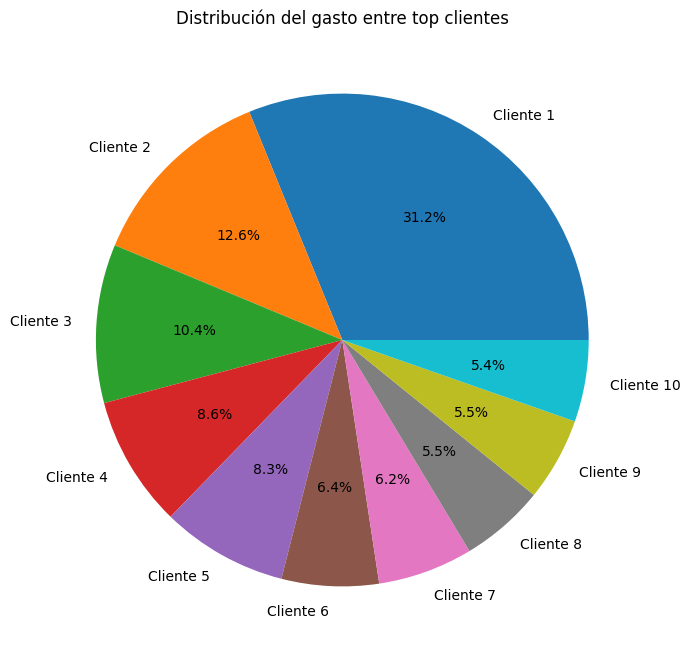

In [30]:
top_clientes_reset = top_clientes.reset_index()
top_clientes_reset["cliente"] = ["Cliente " + str(i+1) for i in range(len(top_clientes_reset))]

plt.figure(figsize=(8,8))

plt.pie(
    top_clientes_reset["payment_value"],
    labels=top_clientes_reset["cliente"],
    autopct="%1.1f%%"
)

plt.title("Distribución del gasto entre top clientes")

plt.show()

El cliente con mayor gasto concentra aproximadamente el 31,2% del total dentro del top 10, seguido de una distribución más equilibrada entre el resto. Esto indica que existe cierta concentración de ingresos en pocos clientes, aunque no es extremadamente desigual.

- Curva de pareto de clientes 

In [31]:
df_clientes = df.groupby("customer_id")["payment_value"].sum().reset_index()

df_clientes = df_clientes.sort_values("payment_value", ascending=False)

df_clientes["cum_pct"] = df_clientes["payment_value"].cumsum() / df_clientes["payment_value"].sum()
df_clientes["cliente_pct"] = (df_clientes.index + 1) / len(df_clientes)

In [32]:
# Ordenar por cliente_pct
df_clientes_sorted = df_clientes.sort_values("cliente_pct")

# Agrupar en bins (ej: cada 1%)
df_clientes_sorted["bin"] = pd.cut(df_clientes_sorted["cliente_pct"], bins=100)

pareto_smooth = df_clientes_sorted.groupby("bin").agg({
    "cliente_pct": "mean",
    "cum_pct": "mean"
}).reset_index()



C:\Users\patri\AppData\Local\Temp\ipykernel_17980\3213420421.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pareto_smooth = df_clientes_sorted.groupby("bin").agg({


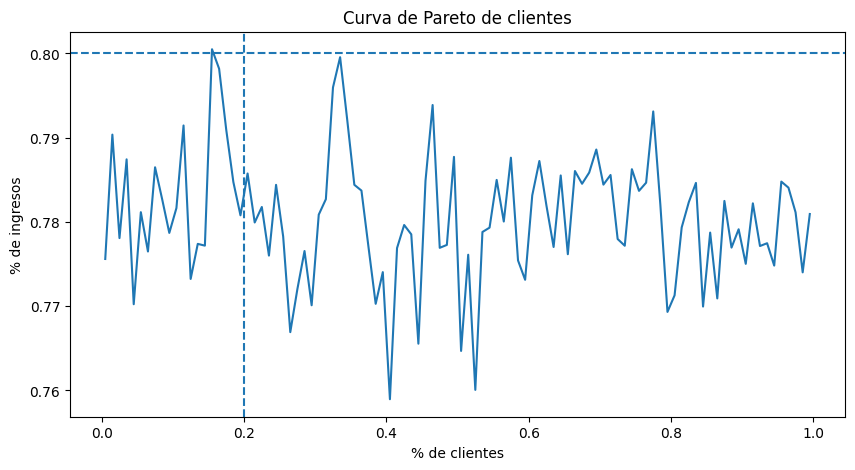

In [33]:
plt.figure(figsize=(10,5))

plt.plot(pareto_smooth["cliente_pct"], pareto_smooth["cum_pct"])

plt.axhline(0.8, linestyle="--")
plt.axvline(0.2, linestyle="--")

plt.title("Curva de Pareto de clientes")
plt.xlabel("% de clientes")
plt.ylabel("% de ingresos")

plt.show()

Se observa que aproximadamente el 20% de los clientes genera cerca del 80% de los ingresos, cumpliendo el principio de Pareto. Esto sugiere que una pequeña parte de los clientes es responsable de la mayor parte del negocio, siendo clave para estrategias de fidelización

- Clientes por estado

In [34]:

customers = df_olist[["id_customer_order","id_user", "order_status","customer_zip", "city", "state", "order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]] 
customers



,id_customer_order,id_user,order_status,customer_zip,city,state,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
0,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,3149,Sao Paulo,SP,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18
1,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,3149,Sao Paulo,SP,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18
2,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,3149,Sao Paulo,SP,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18
3,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,47813,Barreiras,BA,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13
4,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,75265,Vianopolis,GO,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04
...,...,...,...,...,...,...,...,...,...
114853,1fca14ff2861355f6e5f14306ff977a7,da62f9e57a76d978d02ab5362c509660,delivered,11722,Praia Grande,SP,2018-02-06 12:58:58,2018-02-28 17:37:56,2018-03-02
114854,1aa71eb042121263aafbe80c1b562c9c,737520a9aad80b3fbbdad19b66b37b30,delivered,45920,Nova Vicosa,BA,2017-08-27 14:46:43,2017-09-21 11:24:17,2017-09-27
114855,b331b74b18dc79bcdf6532d51e1637c1,5097a5312c8b157bb7be58ae360ef43c,delivered,28685,Japuiba,RJ,2018-01-08 21:28:27,2018-01-25 23:32:54,2018-02-15
114856,b331b74b18dc79bcdf6532d51e1637c1,5097a5312c8b157bb7be58ae360ef43c,delivered,28685,Japuiba,RJ,2018-01-08 21:28:27,2018-01-25 23:32:54,2018-02-15


In [35]:
topEstados = customers.groupby("state")["id_user"].nunique().sort_values(ascending = False).head()
topEstados

state
SP    38933
RJ    11793
MG    10937
RS     5150
PR     4748
Name: id_user, dtype: int64

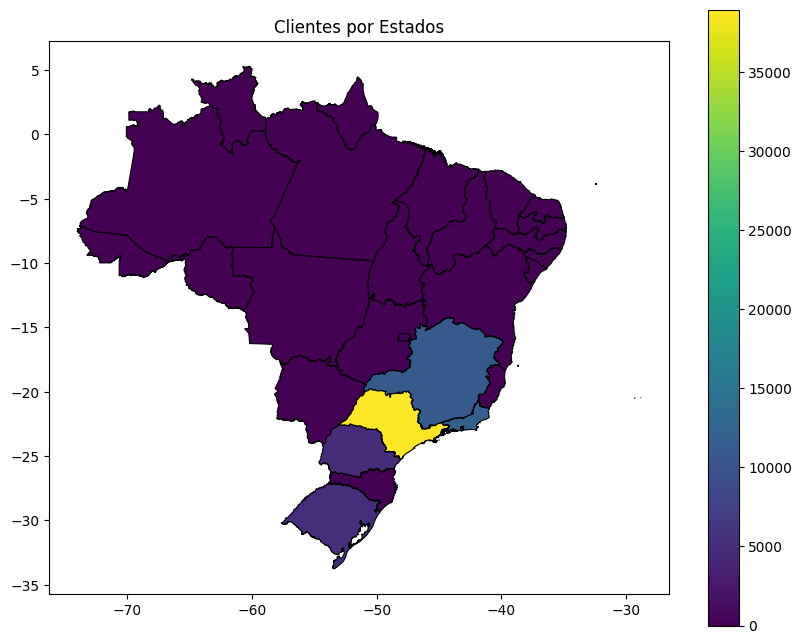

In [36]:
# ventas por estado 
estados = gpd.read_file("../docs/br_states.geojson")
topEstadosMapa = topEstados.reset_index()  


estados = estados.merge(topEstadosMapa[['state', 'id_user']], left_on='abbrev_state', right_on='state', how='left')
estados.rename(columns={'id_user': 'pedidos'},inplace=True)

estados['pedidos'] = estados['pedidos'].fillna(0)

estados.plot(
    column="pedidos",
    cmap="viridis",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    figsize=(10, 8)
)
 
plt.title("Clientes por Estados")
plt.show()

La mayor concentración de clientes se encuentra en São Paulo, seguido por otros estados del sudeste, lo que refleja una fuerte centralización geográfica. Esto indica que las principales regiones económicas del país concentran tanto la demanda como la actividad del negocio.

---

7. Satisfacción 

- KPIs

In [37]:

avg_review = df_olist["review_score"].mean()
pct_5 = (df_olist["review_score"]==5).mean()*100
pct_1 = (df_olist["review_score"]==1).mean()*100

print("Review media:", round(avg_review,2))
print("% 5 estrellas:", round(pct_5,2))
print("% 1 estrella:", round(pct_1,2))

Review media: 4.08
% 5 estrellas: 57.5
% 1 estrella: 11.42


- La valoración media de los clientes es de 4,08 sobre 5, lo que indica un alto nivel general de satisfacción con el servicio.
- Más de la mitad de los pedidos reciben la máxima puntiación, lo que refleja una experiencia positiva para la mayoria de los clientes.
- Un 11,42% de las valoraciones son muy negativas, lo que sugiere la existencia de problemas puntuales que pueden estar relacionados principalmente con logística o la experiencia de la entrega.

- Distribución de reviews

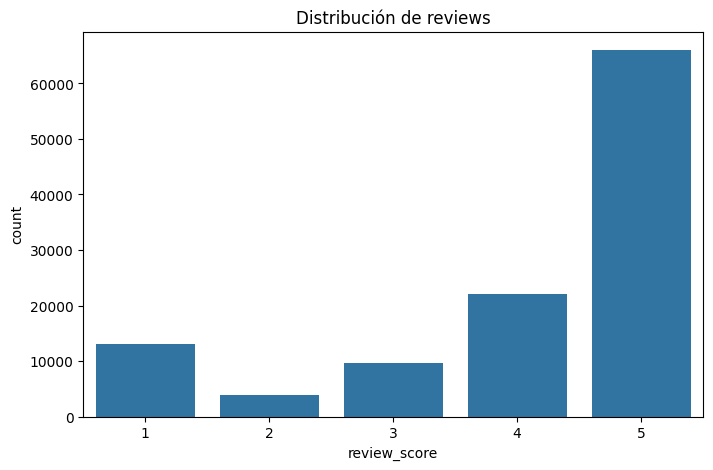

In [38]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="review_score")
plt.title("Distribución de reviews")
plt.show()

La mayoría de las valoraciones se concentran en 5 estrellas, seguidas de 4, lo que indica un alto nivel general de satisfacción. Sin embargo, también existe un volumen relevante de valoraciones bajas (1 estrella), lo que refleja la presencia de experiencias negativas puntuales.


- Relación entre retraso y satisfacción

In [39]:

review_delay = df.groupby("delivery_delay").agg({
    "review_score": "mean",
    "order_id": "nunique"
}).reset_index()

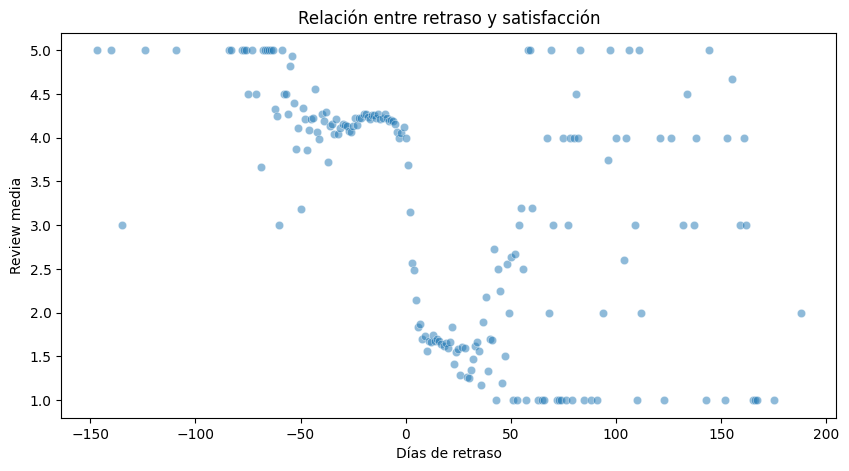

In [40]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=review_delay,
    x="delivery_delay",
    y="review_score",
    alpha=0.5
)

plt.title("Relación entre retraso y satisfacción")
plt.xlabel("Días de retraso")
plt.ylabel("Review media")

plt.show()

Se observa una relación clara entre el retraso en la entrega y la satisfacción del cliente:

Cuando los pedidos se entregan antes o en plazo, las valoraciones tienden a ser altas (4-5).
A medida que aumentan los días de retraso, las puntuaciones disminuyen notablemente, llegando a valores cercanos a 1.

Esto indica que la logística es uno de los principales factores que influyen en la satisfacción del cliente.

- Satisfacción por categoría y estado 

In [41]:
# Reviews por categorías 
review_categoria = df.groupby("category_en").agg({
    "review_score": "mean"
}).sort_values("review_score", ascending=False).head(10)

In [42]:
# Categorías vs estados 
heatmap_cat_state = df.groupby(["category_en", "state"]).agg({
    "review_score": "mean"
}).reset_index()

heatmap_cat_state = heatmap_cat_state.pivot(
    index="category_en",
    columns="state",
    values="review_score"
)

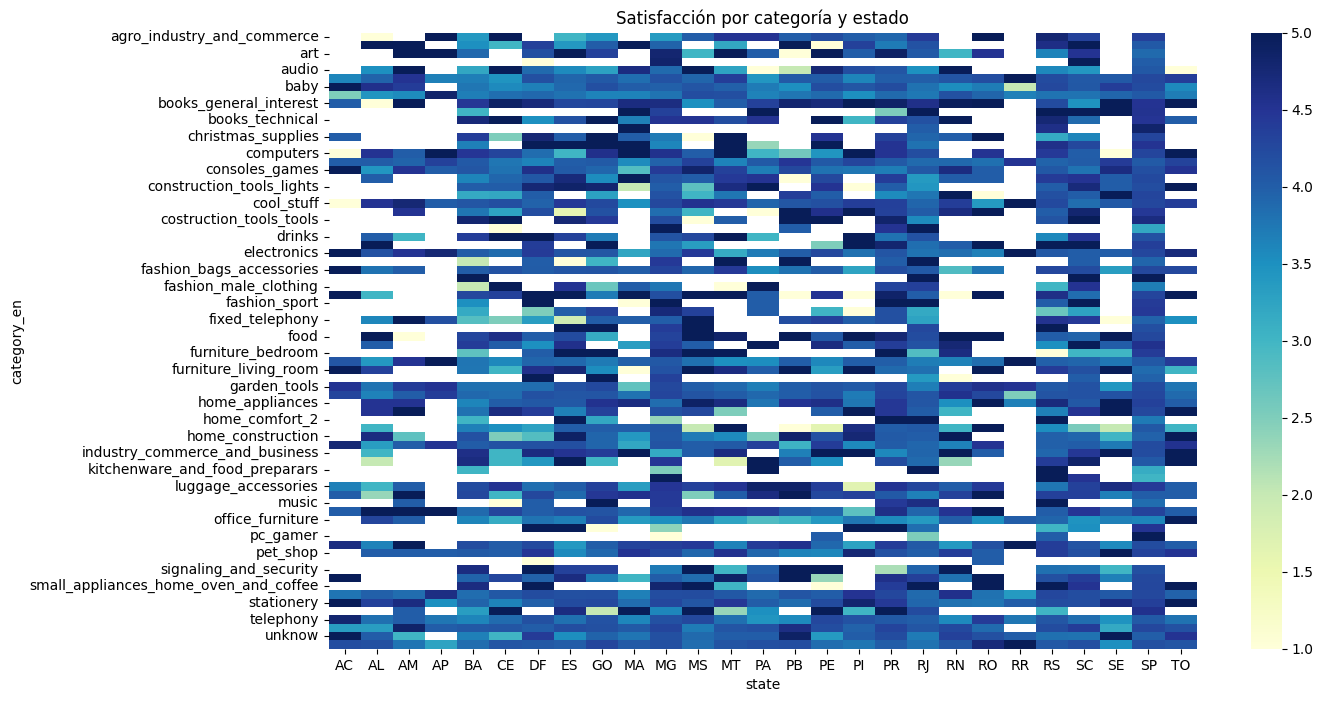

In [43]:
plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_cat_state,
    cmap="YlGnBu",
    annot=False
)

plt.title("Satisfacción por categoría y estado")

plt.show()

La satisfacción varía según la categoría del producto y la ubicación geográfica, aunque en general se mantienen valoraciones altas en la mayoría de combinaciones. No obstante, existen ciertas categorías y estados con puntuaciones más bajas, lo que puede indicar problemas específicos en determinados segmentos del negocio.

## Conclusión 
¿Qué factores influyen en la satisfacción del cliente en Olist?
- El retraso en la entrega es el factor más determinante: a mayor retraso, menor satisfacción.
- El tiempo de entrega total también influye directamente, siendo mejor valorados los pedidos que llegan más rápido.
- El cumplimiento de la fecha estimada es clave: los pedidos entregados en plazo o antes reciben valoraciones más altas.
- Existen diferencias según la ubicación geográfica, lo que indica que la logística varía por estado y afecta a la experiencia del cliente.
- La categoría del producto también influye, ya que algunas presentan niveles de satisfacción más bajos que otras.
- Factores como el comportamiento del pedido (importe, número de productos, etc.) tienen menor impacto en comparación con la logística.

La logística es el principal driver de la satisfacción del cliente, siendo el retraso en la entrega el factor más crítico.

---

# Modelo de Machine Learning Olist 

In [49]:
print(df_olist.columns.to_list())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_time_days', 'delivery_delay', 'id_customer_order', 'id_user', 'customer_zip', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'id_product', 'weight_g', 'lengh_cm', 'heigh_cm', 'width_cm', 'category_pt', 'category_en', 'id_seller', 'seller_zip', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'city', 'state', 'year_month', 'delay_flag', 'target']


In [50]:
for col in df_olist.columns:
    print(col)

order_id
customer_id
order_status
order_purchase_timestamp
order_approved_at
order_delivered_carrier_date
order_delivered_customer_date
order_estimated_delivery_date
delivery_time_days
delivery_delay
id_customer_order
id_user
customer_zip
order_item_id
product_id
seller_id
shipping_limit_date
price
freight_value
id_product
weight_g
lengh_cm
heigh_cm
width_cm
category_pt
category_en
id_seller
seller_zip
payment_sequential
payment_type
payment_installments
payment_value
review_id
review_score
review_comment_title
review_comment_message
review_creation_date
review_answer_timestamp
city
state
year_month
delay_flag
target


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

# Variable objetivo
y = df_olist["target"]

# Variables numéricas
num_cols = [
    "delivery_time_days",
    "delivery_delay",
    "price",
    "freight_value",
    "payment_value",
    "payment_installments",
    "weight_g",
    "lengh_cm",
    "heigh_cm",
    "width_cm"
]

# Variables categóricas
cat_cols = [
    "category_en",
    "payment_type",
    "state",
    "order_status"
]

# Variables predictoras
X = df_olist[num_cols + cat_cols]

# Separar train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocesamiento
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

# Modelo XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

# Entrenamiento
pipeline.fit(X_train, y_train)

# Predicción
y_pred = pipeline.predict(X_test)

# Evaluación
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 1455  3878]
 [  317 17322]]
              precision    recall  f1-score   support

           0       0.82      0.27      0.41      5333
           1       0.82      0.98      0.89     17639

    accuracy                           0.82     22972
   macro avg       0.82      0.63      0.65     22972
weighted avg       0.82      0.82      0.78     22972



- El modelo funciona bien (82% de acierto) y predice muy bien los clientes satisfechos.
- Sin embargo, le cuesta detectar a los clientes insatisfechos.
- Esto se debe a que hay muchos más clientes satisfechos en los datos (desbalanceo).

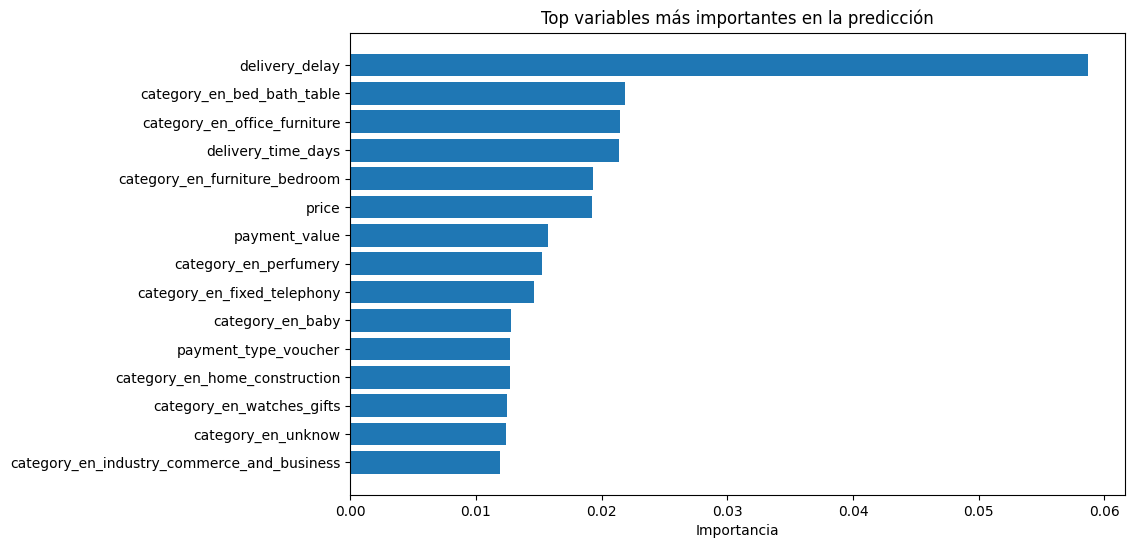

In [54]:


# Obtener nombres de columnas tras el OneHotEncoder
ohe = pipeline.named_steps["preprocessor"].named_transformers_["cat"]
cat_features = ohe.get_feature_names_out(cat_cols)

feature_names = np.concatenate([num_cols, cat_features])

# Importancia de variables
importances = pipeline.named_steps["model"].feature_importances_

# Top 15 variables
indices = np.argsort(importances)[-15:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title("Top variables más importantes en la predicción")
plt.xlabel("Importancia")
plt.show()

- La variable más importante es delivery_delay, es decir, el retraso en la entrega.
- También destacan el tiempo de entrega, el precio y el valor del pedido.
- Algunas categorías de producto también influyen en la satisfacción.

Con ello confirmamos nuestros resultados del EDA a que la logística es el factor que más influye en la satisfacción del cliente 